# Compare outFLANK and Bayescan putative outliers

In [18]:
library("ggplot2")
library("dplyr")

outflank dataframe 

In [20]:
all_loci <- read.csv("outFLANK/outFLANK_FST.csv") %>%
    select(LocusName, He, FST, FSTNoCorr, OutlierFlag)

all_outflank <- filter(all_loci, OutlierFlag == TRUE)
all_outflank

LocusName,He,FST,FSTNoCorr,OutlierFlag
<chr>,<dbl>,<dbl>,<dbl>,<lgl>
Talbacares_lg_4_3319997,0.3829344,0.06899781,0.07586362,TRUE
Talbacares_lg_11_7575958,0.1169034,0.05371249,0.06158628,TRUE
Talbacares_lg_22_772470,0.3509793,0.09699474,0.10391482,TRUE


Outflank and Bayescan results 

In [21]:
out_bayescan <- readLines("bayescan/bayescan_outliers.txt")
bayescan_idx <- c()

all shared putative outliers regardless of He <- used in graphic

In [23]:
all_shared <- intersect(out_bayescan, all_outflank$LocusName)
all_onlybayes <- setdiff(out_bayescan, all_shared)
all_onlyoutflnk <- setdiff(all_outflank$LocusName, all_shared)
all_nonout <- setdiff(all_loci$LocusName, c(all_onlybayes, all_onlyoutflnk, all_shared))


only shared putative outliers (He threshold) <- used in publication

In [25]:
out_shared <- intersect(out_bayescan, all_outflank$LocusName)
out_only_baye <- setdiff(out_bayescan, out_shared)
out_only_outf <- setdiff(all_outflank$LocusName, out_shared)
non_out <- setdiff(all_loci$LocusName, c(out_bayescan, all_outflank$LocusName, out_shared))


fancy ggplot

In [26]:
mycolors <- c("#f4cf30", "#63b057", "#bbbbbb", "#4172c1")

all_loci <- all_loci %>%
  mutate(
    outlier = case_when(
      (LocusName %in% all_onlybayes) ~ "bayescan",
      (LocusName %in% all_onlyoutflnk) ~ "outflank",
      (LocusName %in% all_shared) ~ "bayescan + outflank",
      (LocusName %in% all_nonout) ~ "neutral"
    )
  )


In [29]:
table(all_loci$outlier)


           bayescan bayescan + outflank             neutral            outflank 
                  8                   2                3910                   1 

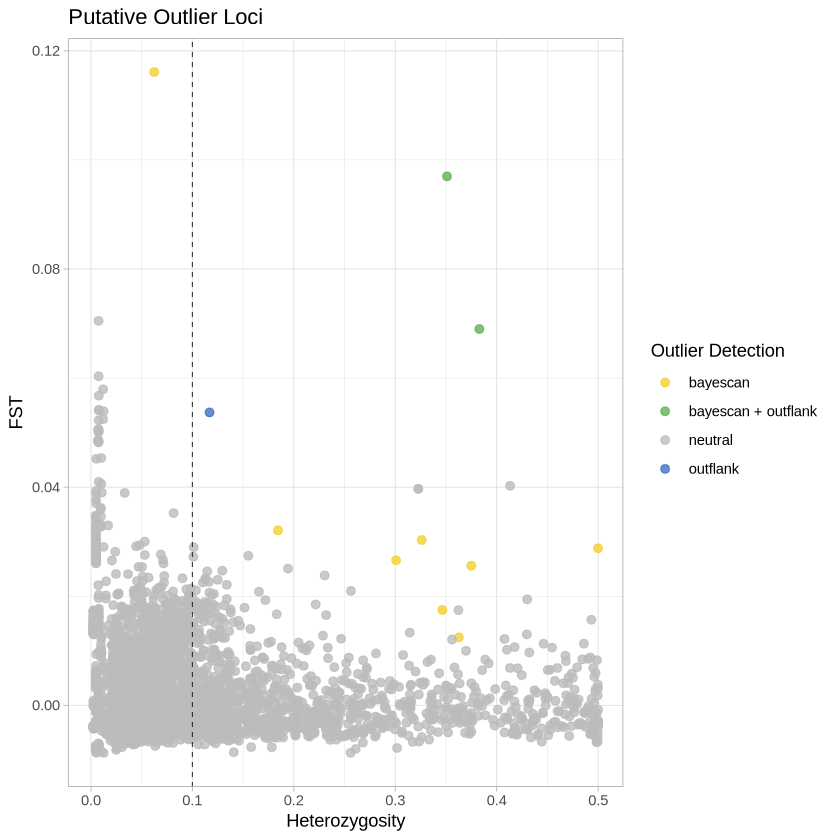

In [32]:
all_loci %>%
    ggplot(aes(x = He, y = FST, col = outlier)) +
    geom_point(alpha = 0.8, size = 2.1) +
    geom_vline(xintercept = 0.1, alpha = 0.8, linetype = "dashed", linewidth = 0.3) +
    labs(
        title = "Putative Outlier Loci", x = "Heterozygosity", y = "FST", color = "Outlier Detection"
    ) +
    scale_color_manual(values = mycolors) +
    theme_light()

In [ ]:
ggsave("outlierplots.png", height = 6, width = 12, units = "in")
write.table(
    all_loci,
    file = "bscan_outflank.all.tsv",
    row.names = FALSE,
    quote = FALSE
)

write.table(
    all_loci[all_loci$outlier != "neutral",],
    file = "bscan_outflank.outliers.tsv",
    row.names = FALSE,
    quote = FALSE
)

write.table(
    all_loci[all_loci$outlier != "neutral", "LocusName"],
    file = "bscan_outflank.outliers",
    row.names = FALSE,
    col.names = FALSE,
    quote = FALSE
)